# Import libraries.

In [1]:
import csv

import math
import numpy as np
import pandas as pd
import psycopg2
import neo4j
import json
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import ast

# Postgres functions to query the cleanmovies database.

In [2]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)
cursor = connection.cursor()

In [3]:
def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integers
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)

In [4]:
connection.rollback()

query = """

drop table if exists cleanmovies;

"""

cursor.execute(query)

connection.commit()


In [5]:
connection.rollback()

query = """

create table cleanmovies (
    index integer,
    title varchar(4000),
    budget varchar(4000),
    genres varchar(4000),
    id integer,
    keywords varchar(4000),
    overview varchar(4000),
    popularity varchar(4000),
    vote_average varchar(4000),
    vote_count varchar(4000),
    cast_ varchar(4000),
    director varchar(4000),
    executive_producer varchar(4000),
    writer varchar(4000),
    original_music_composer varchar(4000),
    director_photography varchar(4000),
    production_country varchar(4000),
    production_company varchar(4000),
    languages varchar(4000)  
)

"""

cursor.execute(query)

connection.commit()

In [6]:
connection.rollback()

query = """

copy cleanmovies
from '/user/projects/project-3-richardshelby/data/interim/cleanmovies.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

In [7]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,None,None,None,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,None,None,None,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,None,"['Robert Moresco', 'Allan Steele']",None,None,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",None,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",None,None,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,None,None,None,None,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",None,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,None,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",None,None,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


In [8]:
connection.rollback()

query = """

select *
from cleanmovies

"""

cursor.execute(query)

connection.rollback()

rows = cursor.fetchall()


# Get similarities from vector embeddings.

In [9]:
vector_embeddings = pd.read_csv("../../data/interim/Summarized_Text_3.0_Vector_Embeddings.csv")

In [10]:
vector_embeddings_clean = np.nan_to_num(vector_embeddings.values)
similarities = cosine_similarity(vector_embeddings_clean, vector_embeddings_clean)
pd.DataFrame(similarities)

,0,1,2,3,4,5,6,7,8,9,...,3213,3214,3215,3216,3217,3218,3219,3220,3221,3222
0,1.000000,0.212203,0.120765,0.094107,0.078594,0.058424,0.040448,0.043880,0.026294,0.024612,...,0.000063,0.000104,0.000084,0.000065,0.000034,0.000085,0.000132,0.000126,0.000111,0.000106
1,0.212203,1.000000,0.707875,0.733565,0.720402,0.718863,0.736824,0.710632,0.720956,0.723620,...,0.707149,0.707156,0.707161,0.707159,0.707129,0.707175,0.707151,0.707145,0.707154,0.707168
2,0.120765,0.707875,1.000000,0.867063,0.889453,0.901552,0.897012,0.894326,0.904186,0.895127,...,0.894467,0.894461,0.894463,0.894473,0.894456,0.894451,0.894457,0.894454,0.894459,0.894446
3,0.094107,0.733565,0.867063,1.000000,0.950010,0.946570,0.950215,0.950895,0.949553,0.955450,...,0.948703,0.948706,0.948730,0.948711,0.948705,0.948712,0.948702,0.948704,0.948703,0.948697
4,0.078594,0.720402,0.889453,0.950010,1.000000,0.965180,0.968973,0.972014,0.971197,0.977193,...,0.970165,0.970167,0.970172,0.970165,0.970156,0.970161,0.970159,0.970157,0.970162,0.970163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,0.000085,0.707175,0.894451,0.948712,0.970161,0.980600,0.986409,0.989959,0.992288,0.993893,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3219,0.000132,0.707151,0.894457,0.948702,0.970159,0.980596,0.986406,0.989962,0.992286,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3220,0.000126,0.707145,0.894454,0.948704,0.970157,0.980594,0.986407,0.989960,0.992287,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3221,0.000111,0.707154,0.894459,0.948703,0.970162,0.980597,0.986405,0.989960,0.992286,0.993892,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# neo4j functions to build the graph database.

In [11]:
def words_from_list(list_of_words):
    "helper function to convert a list of words to a combined string"
    if list_of_words == "Unknown":
        return list_of_words
    text_to_return = ""
    for count, word in enumerate(ast.literal_eval(list_of_words)):
        text_to_return += word
        if count < len(ast.literal_eval(list_of_words)) - 1:
            text_to_return += ", "
    return text_to_return

In [ ]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("***","***"))
session = driver.session(database="neo4j")


def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    result = session.run(query, **kwargs)    
    return pd.DataFrame([r.values() for r in result], columns=result.keys())


def my_neo4j_wipe_out_database():
    "wipe out database by deleting all nodes and relationships"
    
    query = "match (node)-[relationship]->() delete node, relationship"
    session.run(query)
    
    query = "match (node) delete node"
    session.run(query)

    
def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.title as movie_title, labels(n) as labels
        order by n.title
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    # df.to_csv("Graph_Nodes.csv")
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1)-[r]->(n2) 
        return n1.title as movie_title_1, labels(n1) as node_1_labels, 
            type(r) as relationship_type, n2.title as movie_title_2, labels(n2) as node_2_labels,
            r.weight as similarity_score
        order by movie_title_1, movie_title_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    # df.to_csv("Graph_Relationships.csv")
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f'{density:.1f}')
    print("-------------------------")
    
    
def my_neo4j_create_relationship_two_way(from_movie_id, to_movie_id, weight):
    "create relationships two way between two movies with a weight"
    
    query = """
    
    MATCH (from:Movie), 
          (to:Movie)
    WHERE from.id = $from_movie_id and to.id = $to_movie_id
    MERGE (from)-[r1:SIMILAR]->(to)
    MERGE (to)-[r2:SIMILAR]->(from)
    SET r1.weight = $weight,
        r2.weight = $weight
    
    """
    session.run(query, from_movie_id=from_movie_id, to_movie_id=to_movie_id, weight=weight)
    

def delimit_single_quotes(string_value):
    return string_value.replace("'", "\\'")

    
def my_neo4j_create_movie_nodes(movies, movie_count):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for
    """

    nquery = "CREATE \n"
    first = True

    for _, movie in movies.head(movie_count).iterrows():
        if first:
            first = False
        else:
            nquery += ",\n"
        nquery += "(:Movie {"
        nquery += f"title: '{delimit_single_quotes(movie['title'])}', "
        nquery += f"budget: {movie['budget']}, "
        nquery += f"genres: '{delimit_single_quotes(movie['genres'])}', "
        nquery += f"id: {movie['id']}, "
        nquery += f"keywords: '{delimit_single_quotes(movie['keywords'])}', "
        nquery += f"overview: '{delimit_single_quotes(movie['overview'])}', "
        nquery += f"popularity: {movie['popularity']}, "
        nquery += f"vote_average: {movie['vote_average']}, "
        nquery += f"vote_count: {movie['vote_count']}, "
        nquery += f"movie_cast: '{delimit_single_quotes(movie['cast_'])}', "
        nquery += f"director: '{delimit_single_quotes(movie['director'])}', "
        nquery += f"executive_producer: '{delimit_single_quotes(words_from_list(movie['executive_producer']))}', "
        nquery += f"writer: '{delimit_single_quotes(words_from_list(movie['writer']))}', "
        nquery += f"original_music_composer: '{delimit_single_quotes(words_from_list(movie['original_music_composer']))}', "
        nquery += f"director_photography: '{delimit_single_quotes(words_from_list(movie['director_photography']))}', "
        nquery += f"production_country: '{delimit_single_quotes(words_from_list(movie['production_country']))}', "
        nquery += f"production_company: '{delimit_single_quotes(words_from_list(movie['production_company']))}'"
        nquery += "})"
    nquery += ";"
    session.run(nquery)
    

def my_neo4j_create_top_3_similarity_links(movies, movie_count, cosine_similarity_matrix):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for        
        cosine_similarity_matrix: similarity matrix in the range [-1, 1] where 
            -1 is opposite taste
             0 is no similarity
             1 is perfect match
             
        note - this is hardcoded to top 3 but we can make it general if needed
    """

    for movie_idx in range(movie_count):
        # track top 3 movie by index and score
        similar_1_idx = -1
        similar_2_idx = -1
        similar_3_idx = -1
        similar_1_score = -1
        similar_2_score = -1
        similar_3_score = -1

        for movie_idx_compare in range(movie_count):
            
            # only compare movies to other movies
            if movie_idx == movie_idx_compare:
                continue
                
            similarity_score = cosine_similarity_matrix[movie_idx][movie_idx_compare]

            if similarity_score > similar_1_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = similar_1_idx            
                similar_2_score = similar_1_score

                similar_1_idx = movie_idx_compare            
                similar_1_score = similarity_score

            elif similarity_score > similar_2_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = movie_idx_compare
                similar_2_score = similarity_score

            elif similarity_score > similar_3_score:
                similar_3_idx = movie_idx_compare
                similar_3_score = similarity_score

        most_similar_array = [
            (similar_1_idx, similar_1_score),
            (similar_2_idx, similar_2_score),
            (similar_3_idx, similar_3_score)
        ]
        
        for similar_idx, similar_score in most_similar_array:
            my_neo4j_create_relationship_two_way(
                from_movie_id = movies.iloc[movie_idx].id, 
                to_movie_id = movies.iloc[similar_idx].id, 
                weight = round(similar_score, 5)
            )

In [28]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
movies_df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

In [29]:
movies_df = movies_df.fillna("Unknown")

In [30]:
movies_df

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,Unknown,Unknown,Unknown,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,Unknown,Unknown,Unknown,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,Unknown,"['Robert Moresco', 'Allan Steele']",Unknown,Unknown,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",Unknown,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",Unknown,Unknown,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,Unknown,Unknown,Unknown,Unknown,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",Unknown,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,Unknown,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",Unknown,Unknown,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


# Create graph for the first fifty movies

In [31]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 50 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 50)
my_neo4j_create_top_3_similarity_links(movies_df, 50, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,(500) Days of Summer,[Movie]
1,10 Cloverfield Lane,[Movie]
2,10 Things I Hate About You,[Movie]
3,102 Dalmatians,[Movie]
4,10th & Wolf,[Movie]
5,12 Angry Men,[Movie]
6,12 Rounds,[Movie]
7,12 Years a Slave,[Movie]
8,127 Hours,[Movie]
9,13 Going on 30,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,(500) Days of Summer,[Movie],SIMILAR,2046,[Movie],0.99889
1,(500) Days of Summer,[Movie],SIMILAR,27 Dresses,[Movie],0.99935
2,(500) Days of Summer,[Movie],SIMILAR,28 Weeks Later,[Movie],0.99947
3,(500) Days of Summer,[Movie],SIMILAR,3 Strikes,[Movie],0.99972
4,(500) Days of Summer,[Movie],SIMILAR,30 Days of Night,[Movie],0.99961
...,...,...,...,...,...,...
265,55 Days at Peking,[Movie],SIMILAR,50 First Dates,[Movie],0.99976
266,55 Days at Peking,[Movie],SIMILAR,54,[Movie],0.99974
267,An Education,[Movie],SIMILAR,(500) Days of Summer,[Movie],0.99937
268,An Education,[Movie],SIMILAR,50 First Dates,[Movie],0.99940


-------------------------
  Density: 0.2
-------------------------


In [32]:
print(movies_df['title'].iloc[:50])
print(similarities[:50, :50])

0                                102 Dalmatians
1                           10 Cloverfield Lane
2                    10 Things I Hate About You
3                                   10th & Wolf
4                                     127 Hours
5                                  12 Angry Men
6                                     12 Rounds
7                              12 Years a Slave
8                                13 Going on 30
9     13 Hours: The Secret Soldiers of Benghazi
10                                         1408
11                                   15 Minutes
12                                    16 Blocks
13                                     17 Again
14                                         1911
15                                         1941
16                 20,000 Leagues Under the Sea
17                        2001: A Space Odyssey
18                               200 Cigarettes
19                                         2012
20                                      

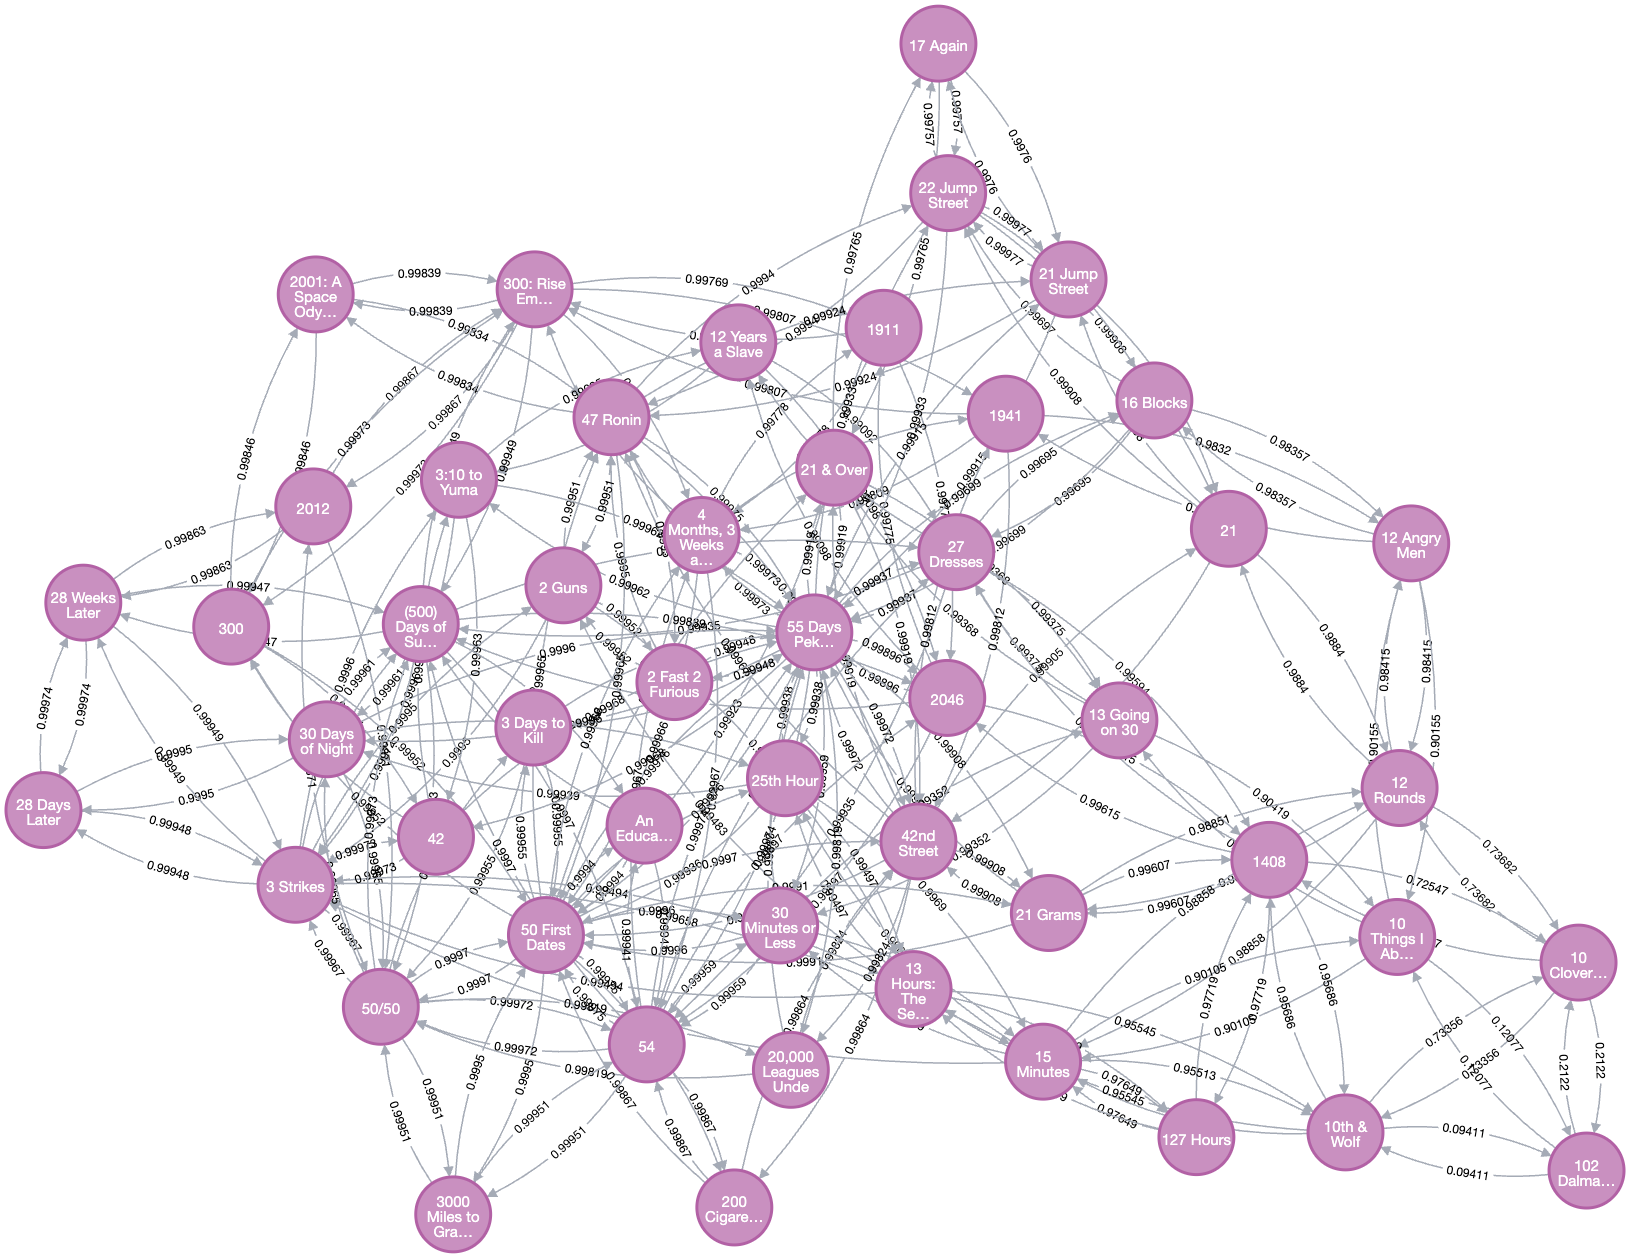

## Harmonic Centrality Analysis

In [33]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'weight'})"
session.run(query)

In [34]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

my_neo4j_run_query_pandas(query)

,movie_title,closeness
0,55 Days at Peking,0.678571
1,50 First Dates,0.620748
2,54,0.566327
3,42nd Street,0.540816
4,(500) Days of Summer,0.532313
5,3 Strikes,0.528912
6,27 Dresses,0.527211
7,47 Ronin,0.522109
8,50/50,0.522109
9,2046,0.508503


# All movies in cleanmovies

In [20]:
# start fresh
my_neo4j_wipe_out_database()

my_neo4j_create_movie_nodes(movies_df, len(movies_df))
my_neo4j_create_top_3_similarity_links(movies_df, len(movies_df), similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,(500) Days of Summer,[Movie]
1,10 Cloverfield Lane,[Movie]
2,10 Things I Hate About You,[Movie]
3,102 Dalmatians,[Movie]
4,10th & Wolf,[Movie]
...,...,...
3218,[REC]²,[Movie]
3219,eXistenZ,[Movie]
3220,xXx,[Movie]
3221,xXx: State of the Union,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,(500) Days of Summer,[Movie],SIMILAR,Agora,[Movie],0.99979
1,(500) Days of Summer,[Movie],SIMILAR,Alatriste,[Movie],0.99979
2,(500) Days of Summer,[Movie],SIMILAR,Amélie,[Movie],0.99979
3,10 Cloverfield Lane,[Movie],SIMILAR,102 Dalmatians,[Movie],0.21220
4,10 Cloverfield Lane,[Movie],SIMILAR,10th & Wolf,[Movie],0.73356
...,...,...,...,...,...,...
17467,xXx: State of the Union,[Movie],SIMILAR,Zodiac,[Movie],1.00000
17468,Æon Flux,[Movie],SIMILAR,3000 Miles to Graceland,[Movie],0.99968
17469,Æon Flux,[Movie],SIMILAR,A Perfect Getaway,[Movie],0.99994
17470,Æon Flux,[Movie],SIMILAR,Argo,[Movie],0.99994


-------------------------
  Density: 0.0
-------------------------


## Harmonic Centrality Analysis

In [21]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'weight'})"
session.run(query)

In [22]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

my_neo4j_run_query_pandas(query)

,movie_title,closeness
0,Warrior,0.292911
1,Vantage Point,0.289661
2,Zero Dark Thirty,0.286392
3,Zombieland,0.284853
4,You Kill Me,0.283099
...,...,...
3218,Batman & Robin,0.001241
3219,Final Destination 3,0.000931
3220,Final Destination 5,0.000931
3221,"First Love, Last Rites",0.000931


In [23]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

harmonic_centrality_closeness_df = my_neo4j_run_query_pandas(query)

In [24]:
harmonic_centrality_closeness_df.to_csv("Harmonic_Centrality_Analysis.csv")

## Sort Harmonic Centrality Results

In [40]:
connection.rollback()

query = """

drop table if exists movie_closeness;

"""

cursor.execute(query)

connection.commit()

In [41]:
connection.rollback()

query = """

create table movie_closeness (
    index integer,
    movie_title varchar(4000),
    closeness numeric(10, 10)
)

"""

cursor.execute(query)

connection.commit()

In [42]:
connection.rollback()

query = """

copy movie_closeness
from '/user/projects/project-3-richardshelby/code/algorithms/Harmonic_Centrality_Analysis.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

In [43]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select movie_title, closeness
from movie_closeness
order by movie_title

"""
movie_closeness_sorted = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)
movie_closeness_sorted.to_csv("Sorted_Harmonic_Centrality_Analysis.csv")

## Analyze Harmonic Centrality Results

In [44]:
connection.rollback()

query = """

drop table if exists movie_closeness;

"""

cursor.execute(query)

connection.commit()

In [45]:
connection.rollback()

query = """

create table movie_closeness (
    index integer,
    movie_title varchar(4000),
    closeness numeric(10, 10)
)

"""

cursor.execute(query)

connection.commit()

In [46]:
connection.rollback()

query = """

copy movie_closeness
from '/user/projects/project-3-richardshelby/code/algorithms/Sorted_Harmonic_Centrality_Analysis.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

In [47]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from movie_closeness

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,index,movie_title,closeness
0,0,102 Dalmatians,0.127928
1,1,10 Cloverfield Lane,0.137751
2,2,10 Things I Hate About You,0.143917
3,3,10th & Wolf,0.146165
4,4,127 Hours,0.145803
...,...,...,...
3218,3218,Zombieland,0.284853
3219,3219,Zookeeper,0.252544
3220,3220,Zoolander,0.217862
3221,3221,Zoolander 2,0.235781


In [48]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from movie_closeness
order by closeness desc

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,index,movie_title,closeness
0,3109,Warrior,0.292911
1,3076,Vantage Point,0.289661
2,3215,Zero Dark Thirty,0.286392
3,3218,Zombieland,0.284853
4,3203,You Kill Me,0.283099
...,...,...,...
3218,302,Batman Forever,0.001241
3219,843,Final Fantasy: The Spirits Within,0.000931
3220,841,Final Destination 3,0.000931
3221,854,"First Love, Last Rites",0.000931


In [49]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select harmonic.movie_title, harmonic.closeness, movies.genres, movies.keywords
from movie_closeness as harmonic
    join cleanmovies as movies
        on harmonic.index = movies.index
order by harmonic.closeness desc

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,movie_title,closeness,genres,keywords
0,Warrior,0.292911,Action Drama,bank training beating mixed martial arts teacher
1,Vantage Point,0.289661,Drama Action Thriller Crime,bomb terror spain usa president terrorist
2,Zero Dark Thirty,0.286392,Thriller Drama History,assassination cia hotel terrorist prisoner
3,Zombieland,0.284853,Comedy Horror,washington d.c. sister sister relationship pos...
4,You Kill Me,0.283099,Comedy Crime Thriller Romance,new york san francisco alcoholism serial kille...
...,...,...,...,...
3218,Batman Forever,0.001241,Action Crime Fantasy,riddle dc comics rose gotham city partner
3219,Final Fantasy: The Spirits Within,0.000931,Adventure Action Animation Fantasy Science Fic...,battle assignment dystopia alien downfall scie...
3220,Final Destination 3,0.000931,Horror Mystery,beheading dying and death stroke of fate
3221,"First Love, Last Rites",0.000931,Drama,sex misfit boring


In [50]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select harmonic.movie_title, harmonic.closeness, movies.*
from movie_closeness as harmonic
    join cleanmovies as movies
        on harmonic.index = movies.index
order by harmonic.closeness desc

"""
movies_df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

In [51]:
movies_df = movies_df.fillna("Unknown")

# Create graph for the top 20 closest movies

In [72]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 20 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 20)
my_neo4j_create_top_3_similarity_links(movies_df, 20, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,The Warrior's Way,[Movie]
1,This Is the End,[Movie]
2,Tropic Thunder,[Movie]
3,U2 3D,[Movie]
4,Underworld: Rise of the Lycans,[Movie]
5,Vantage Point,[Movie]
6,Virtuosity,[Movie]
7,Wanderlust,[Movie]
8,War,[Movie]
9,War of the Worlds,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,The Warrior's Way,[Movie],SIMILAR,This Is the End,[Movie],0.99726
1,The Warrior's Way,[Movie],SIMILAR,Tropic Thunder,[Movie],0.99767
2,The Warrior's Way,[Movie],SIMILAR,U2 3D,[Movie],0.99550
3,The Warrior's Way,[Movie],SIMILAR,Underworld: Rise of the Lycans,[Movie],0.99642
4,The Warrior's Way,[Movie],SIMILAR,Whatever Works,[Movie],0.99307
...,...,...,...,...,...,...
101,Zombieland,[Movie],SIMILAR,U2 3D,[Movie],0.95686
102,Zombieland,[Movie],SIMILAR,Vantage Point,[Movie],0.73356
103,Zombieland,[Movie],SIMILAR,War of the Worlds,[Movie],0.95513
104,Zombieland,[Movie],SIMILAR,Warrior,[Movie],0.09411


-------------------------
  Density: 0.6
-------------------------


In [73]:
print(movies_df['title'].iloc[:20])
print(similarities[:20, :20])

0                            Warrior
1                      Vantage Point
2                   Zero Dark Thirty
3                         Zombieland
4                        You Kill Me
5                                War
6                         Virtuosity
7                         Wanderlust
8                     Whatever Works
9                       White Chicks
10                             U2 3D
11                 War of the Worlds
12                       Zero Effect
13                Young Frankenstein
14    Underworld: Rise of the Lycans
15                          Whiplash
16        Zathura: A Space Adventure
17                   This Is the End
18                 The Warrior's Way
19                    Tropic Thunder
Name: title, dtype: object
[[1.         0.21220322 0.12076505 0.09410727 0.07859405 0.05842357
  0.04044802 0.04387972 0.02629373 0.02461234 0.03905065 0.0264749
  0.02008663 0.01872706 0.01182881 0.01110266 0.01484521 0.01275765
  0.01328747 0.01624836]
 [0.2

# Create graph for the top 5 farthest movies

In [82]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select harmonic.movie_title, harmonic.closeness, movies.*
from movie_closeness as harmonic
    join cleanmovies as movies
        on harmonic.index = movies.index
order by harmonic.closeness asc

"""
movies_df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

In [83]:
movies_df = movies_df.fillna("Unknown")

In [84]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 5 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 5)
my_neo4j_create_top_3_similarity_links(movies_df, 5, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,Batman Forever,[Movie]
1,Final Destination 3,[Movie]
2,Final Destination 5,[Movie]
3,Final Fantasy: The Spirits Within,[Movie]
4,"First Love, Last Rites",[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,Batman Forever,[Movie],SIMILAR,Final Destination 5,[Movie],0.95001
1,Batman Forever,[Movie],SIMILAR,Final Fantasy: The Spirits Within,[Movie],0.72040
2,Batman Forever,[Movie],SIMILAR,"First Love, Last Rites",[Movie],0.88945
3,Final Destination 3,[Movie],SIMILAR,Final Destination 5,[Movie],0.09411
4,Final Destination 3,[Movie],SIMILAR,Final Fantasy: The Spirits Within,[Movie],0.21220
5,Final Destination 3,[Movie],SIMILAR,"First Love, Last Rites",[Movie],0.12077
6,Final Destination 5,[Movie],SIMILAR,Batman Forever,[Movie],0.95001
7,Final Destination 5,[Movie],SIMILAR,Final Destination 3,[Movie],0.09411
8,Final Destination 5,[Movie],SIMILAR,Final Fantasy: The Spirits Within,[Movie],0.73356
9,Final Destination 5,[Movie],SIMILAR,"First Love, Last Rites",[Movie],0.86706


-------------------------
  Density: 1.8
-------------------------


In [85]:
print(movies_df['title'].iloc[:5])
print(similarities[:5, :5])

0                  Final Destination 3
1    Final Fantasy: The Spirits Within
2               First Love, Last Rites
3                  Final Destination 5
4                       Batman Forever
Name: title, dtype: object
[[1.         0.21220322 0.12076505 0.09410727 0.07859405]
 [0.21220322 1.         0.70787472 0.73356483 0.72040235]
 [0.12076505 0.70787472 1.         0.86706345 0.88945346]
 [0.09410727 0.73356483 0.86706345 1.         0.95000966]
 [0.07859405 0.72040235 0.88945346 0.95000966 1.        ]]


# Presentation visuals

In [56]:
sample_movies = movies_df.sample(100)
sample_movies

,movie_title,closeness,index,title,budget,genres,id,keywords,overview,popularity,...,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
1859,Premium Rush,0.203840,1789,Premium Rush,35000000,Crime Action Thriller,49526,new york dirty cop bicycle courier duringcredi...,"In Manhattan, a bike messenger picks up an env...",17.709888,...,832,Joseph Gordon-Levitt Michael Shannon Dania Ram...,David Koepp,Unknown,"['David Koepp', 'John Kamps']",Unknown,Unknown,['United States of America'],['Pariah Entertainment Group'],"['普通话', 'English']"
297,Training Day,0.234015,2999,Training Day,45000000,Action Crime Drama Thriller,2034,police brutality war on drugs drug traffic dru...,On his first day on the job as a narcotics off...,52.081131,...,1634,Denzel Washington Ethan Hawke Scott Glenn Tom ...,Antoine Fuqua,"['Bruce Berman', 'Davis Guggenheim']",Unknown,['Mark Mancina'],['Mauro Fiore'],"['United States of America', 'Australia']","['NPV Entertainment', 'WV Films II', 'Outlaw P...","['Español', 'English', '한국어/조선말', 'Pусский']"
2063,Focus,0.200137,874,Focus,50100000,Romance Comedy Crime Drama,256591,seduction con man femme fatale deception rivalry,"Nicky, a veteran con artist, takes a novice na...",59.63402900000001,...,2542,Will Smith Margot Robbie Rodrigo Santoro Rober...,Glenn Ficarra,"['Charlie Gogolak', 'Stan Wlodkowski']","['Glenn Ficarra', 'John Requa']",['Nick Urata'],['Xavier Grobet'],['United States of America'],"['RatPac-Dune Entertainment', 'Zaftig Films', ...",['English']
2805,Cloudy with a Chance of Meatballs,0.182378,537,Cloudy with a Chance of Meatballs,100000000,Animation Comedy Family,22794,weather food science,Inventor Flint Lockwood creates a machine that...,46.781182,...,1747,Bill Hader Anna Faris James Caan Mr. T Benjami...,Phil Lord,['Yair Landau'],Unknown,['Mark Mothersbaugh'],Unknown,['United States of America'],"['Sony Pictures Animation', 'Columbia Pictures']",['English']
2295,Blade: Trinity,0.195599,373,Blade: Trinity,65000000,Science Fiction Action Horror Thriller Adventure,36648,fbi dracula fistfight vampire hunter superhero,"For years, Blade has fought against the vampir...",49.660055,...,1252,Wesley Snipes Kris Kristofferson Dominic Purce...,David S. Goyer,"['Stan Lee', 'Toby Emmerich', 'Avi Arad', 'Cal...",['David S. Goyer'],"['RZA', 'Ramin Djawadi']",['Gabriel Beristain'],['United States of America'],"['Shawn Danielle Productions Ltd.', 'Imaginary...","['English', 'Esperanto']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,The 5th Wave,0.232258,2281,The 5th Wave,38000000,Adventure Science Fiction,299687,based on novel dystopia alien alien invasion h...,16-year-old Cassie Sullivan tries to survive i...,57.889964,...,1945,Chlo\u00eb Grace Moretz Nick Robinson Alex Roe...,J Blakeson,['Richard Middleton'],Unknown,['Henry Jackman'],['Enrique Chediak'],['United States of America'],"['Material Pictures', 'GK Films', 'Columbia Pi...",['English']
2360,Battleship,0.193970,310,Battleship,209000000,Thriller Action Adventure Science Fiction,44833,fight u.s. navy mind reading hong kong soccer,"When mankind beams a radio signal into space, ...",64.928382,...,2114,Taylor Kitsch Alexander Skarsg\u00e5rd Rihanna...,Peter Berg,Unknown,Unknown,['Steve Jablonsky'],['Tobias A. Schliessler'],['United States of America'],"['Universal Pictures', 'Hasbro', 'Bluegrass Fi...","['ภาษาไทย', 'English']"
2824,Happy Gilmore,0.181736,1036,Happy Gilmore,12000000,Comedy,9614,loss of mother loss of father golf sport taxes,Failed hockey player-turned-golf whiz Happy Gi...,26.598884,...,755,Adam Sandler Ben Stiller Christopher McDonald ...,Dennis Dugan,"['Bernie Brillstein', 'Brad Grey']",Unknown,['Mark Mothersbaugh'],['Arthur Albert'],['United States of America'],"['Brillstein-Grey Entertainment', 'Robert Simo...",['English']
1106,Homefront,0.215812,1098,Homefront,22000000,Action Thriller,204082,based on nov

In [57]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 50 movies so we can visually verify our code
my_neo4j_create_movie_nodes(sample_movies, 100)
my_neo4j_create_top_3_similarity_links(sample_movies, 100, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,A Nightmare on Elm Street 3: Dream Warriors,[Movie]
1,A Sound of Thunder,[Movie]
2,Agent Cody Banks 2: Destination London,[Movie]
3,Air Force One,[Movie]
4,Aladdin,[Movie]
...,...,...
95,Transamerica,[Movie]
96,Vacation,[Movie]
97,Victor Frankenstein,[Movie]
98,Volver,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,Brick Mansions,[Movie],0.99933
1,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,Friday the 13th: A New Beginning,[Movie],0.99896
2,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,Mad Max: Fury Road,[Movie],0.99982
3,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,Salt,[Movie],0.99980
4,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,Street Kings,[Movie],0.99699
...,...,...,...,...,...,...
553,Volver,[Movie],SIMILAR,That's My Boy,[Movie],0.99986
554,Volver,[Movie],SIMILAR,The 5th Wave,[Movie],0.99986
555,Willy Wonka & the Chocolate Factory,[Movie],SIMILAR,Air Force One,[Movie],0.99989
556,Willy Wonka & the Chocolate Factory,[Movie],SIMILAR,August: Osage County,[Movie],0.99990


-------------------------
  Density: 0.1
-------------------------


In [58]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'weight'})"
session.run(query)

In [59]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

my_neo4j_run_query_pandas(query)

,movie_title,closeness
0,Homefront,0.595960
1,Happy Gilmore,0.583670
2,The 5th Wave,0.515152
3,Battleship,0.512626
4,That's My Boy,0.507576
...,...,...
95,Focus,0.321212
96,Blade: Trinity,0.321212
97,The Twilight Saga: Breaking Dawn - Part 2,0.310774
98,Training Day,0.303199


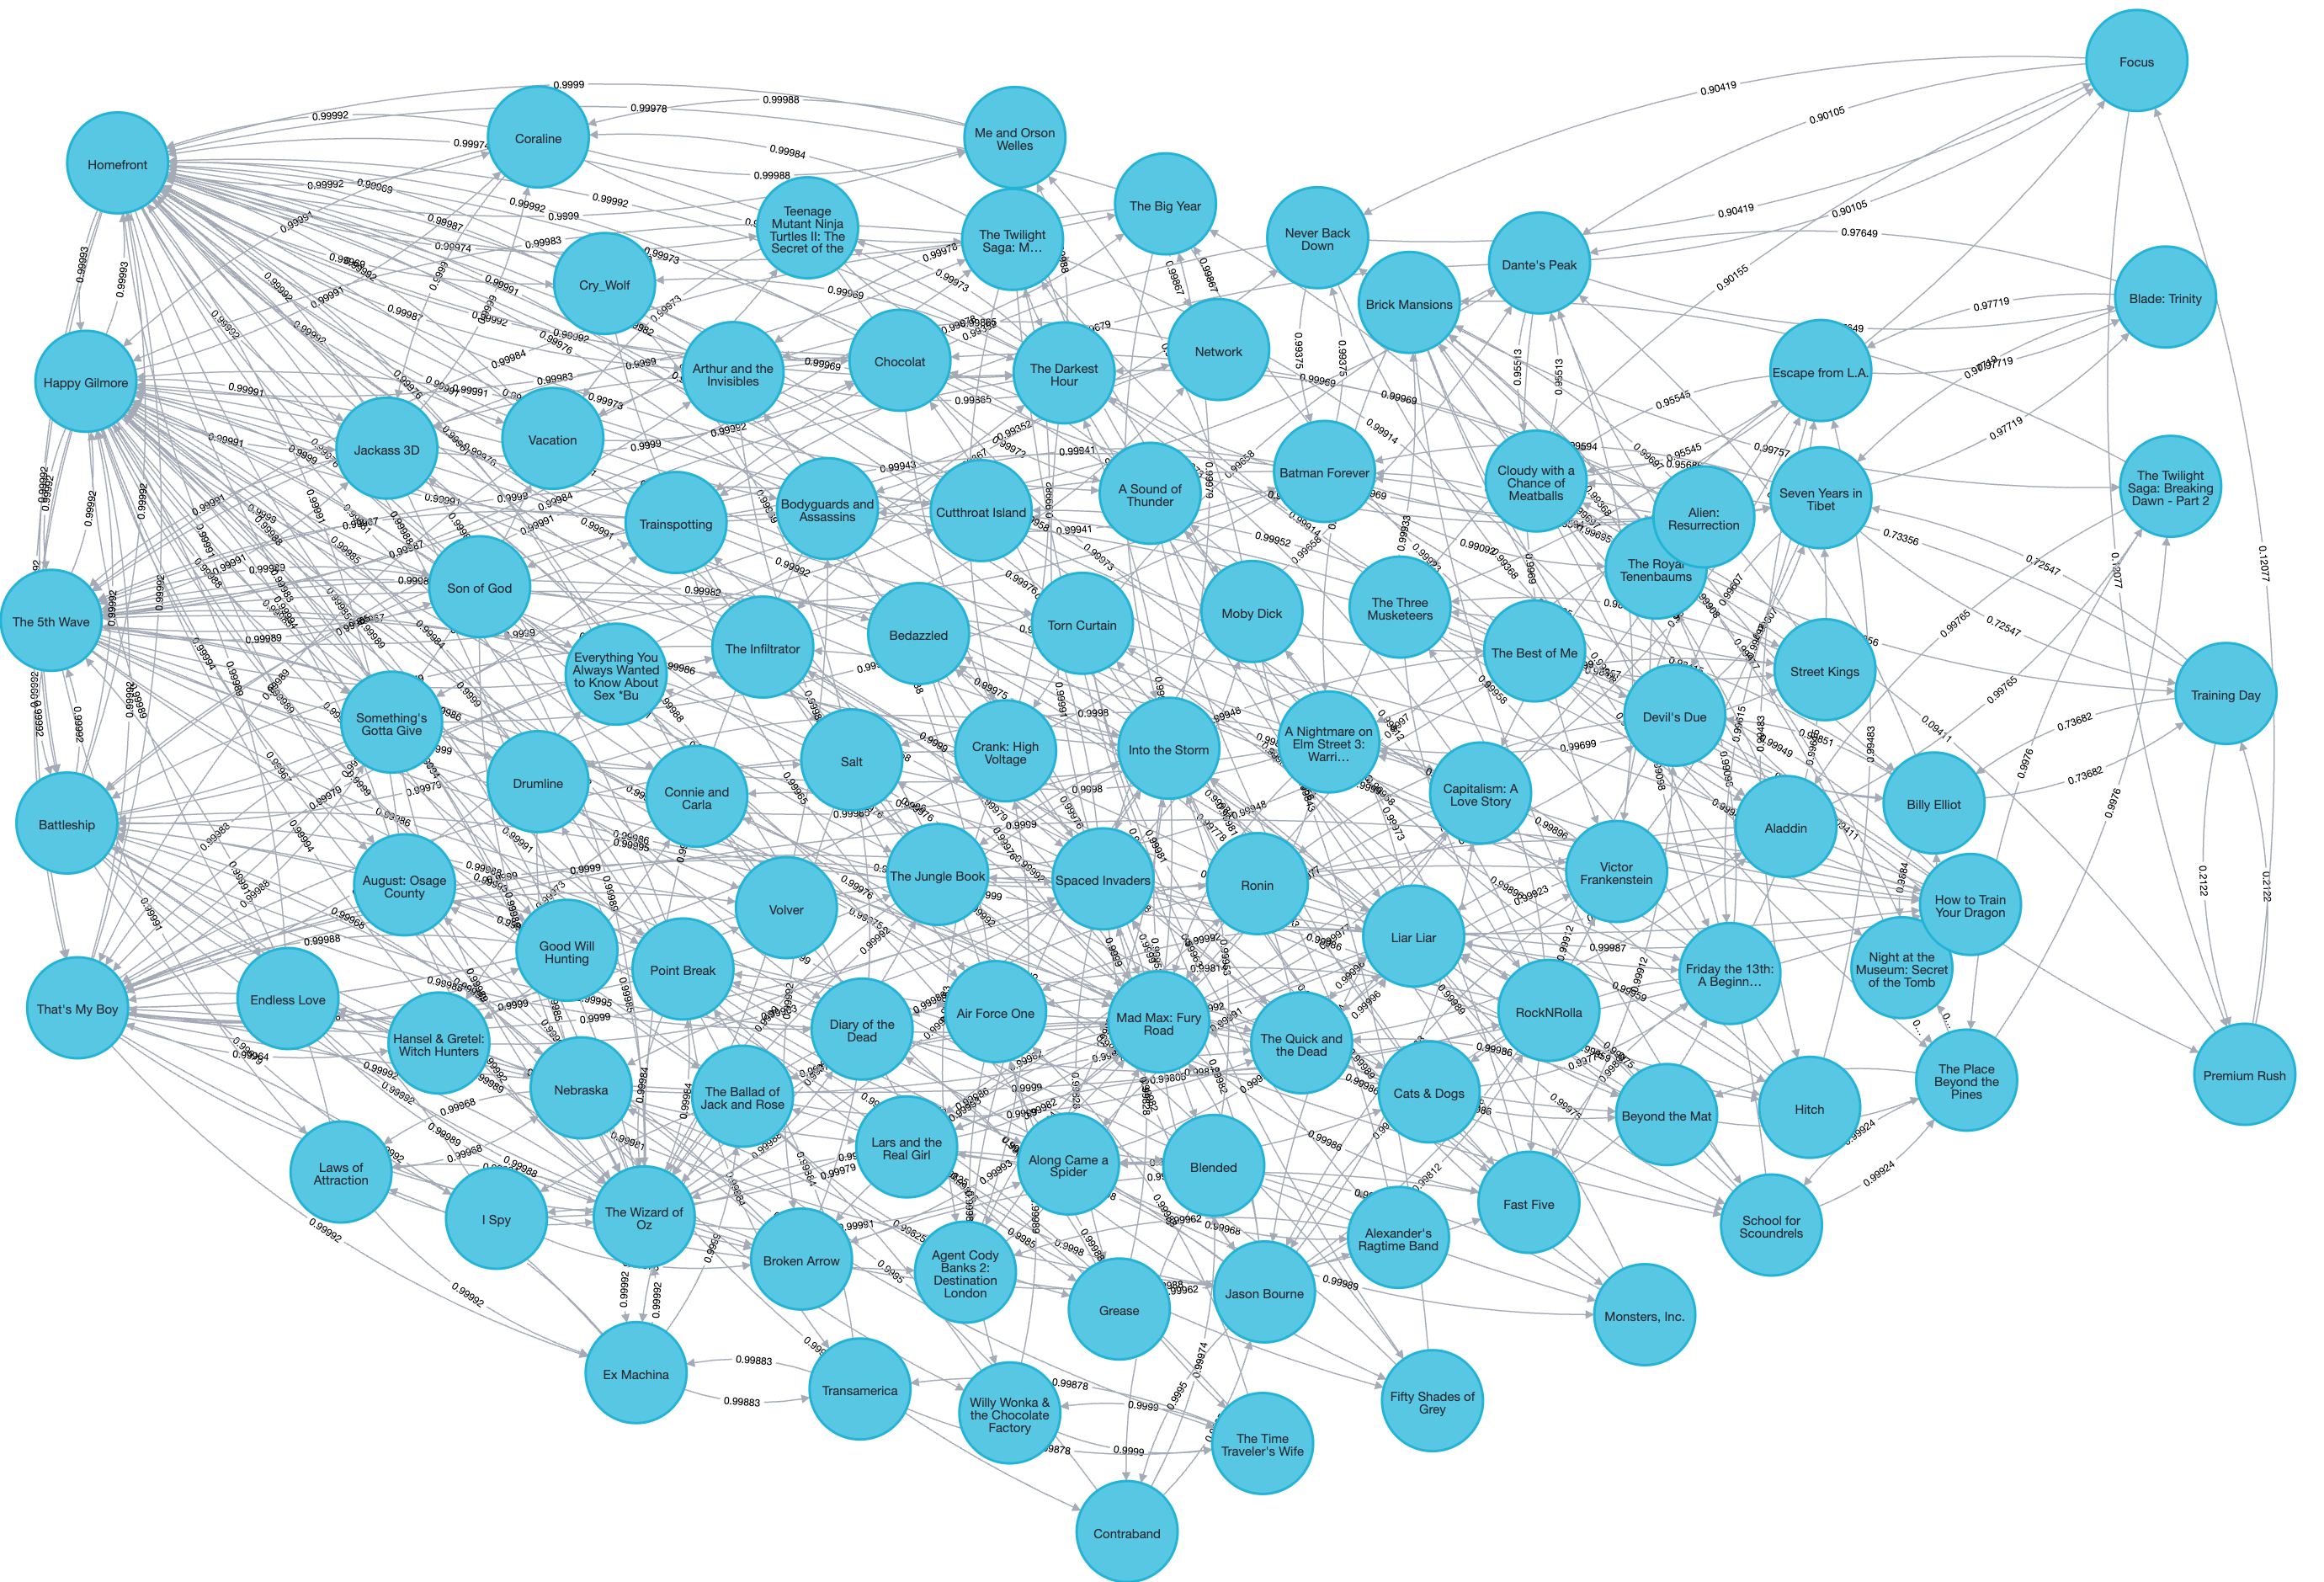